# Tutorial 8.1: Model predictive control for buildings

This tutorial converts the Week 7 fixed schedule into a receding-horizon controller. At every update, the current measured temperature anchors a new prediction, only the first optimised action is applied, and the reference plant advances under realised conditions.

## Learning outcomes

By the end of the tutorial, you should be able to:

1. implement a receding-horizon control loop;
2. align forecasts, actions and state transitions;
3. apply only the first action of each optimal sequence; and
4. compare MPC with a thermostat and a fixed schedule using common summary metrics.

## Indicative schedule

- one MPC update and indexing: 20 minutes;
- receding-horizon loop: 35 minutes;
- solver checks and fallback: 15 minutes;
- controller comparison: 15 minutes;
- discussion: 5 minutes.

## 1. Set-up, data and forecasts

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from course_utils.reference_building import TwoStateReferencePlant
from course_utils.mpc import build_mpc_problem, forecast_vector
from course_utils.control import solve_heating_schedule, simulate_reference_schedule, simulate_thermostat, realised_metrics

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    raise FileNotFoundError("Run this notebook from the repository root.")

plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})

In [2]:
operation = pd.read_csv(
    ROOT / "data" / "reference_building" / "operation_conditions.csv",
    index_col="timestamp",
    parse_dates=True,
).sort_index()
forecasts = pd.read_csv(
    ROOT / "data" / "reference_building" / "operation_forecasts.csv",
    parse_dates=["issue_time", "valid_time"],
)
model = json.loads(
    (ROOT / "data" / "reference_building" / "verified_controller_model.json").read_text()
)

evaluation_conditions = operation.iloc[:48]
first_origin = evaluation_conditions.index[0]
first_forecast = forecasts.loc[forecasts["issue_time"] == first_origin].head(47)
print(f"Forecast origin: {first_origin}")
display(first_forecast.head())

Forecast origin: 2025-02-03 00:00:00


,issue_time,valid_time,lead_steps,outdoor_temperature_forecast_c,solar_irradiance_forecast_w_m2,pv_available_forecast_kw
0,2025-02-03,2025-02-03 00:30:00,1,6.00185,0.0,0.0
1,2025-02-03,2025-02-03 01:00:00,2,5.93279,0.0,0.0
2,2025-02-03,2025-02-03 01:30:00,3,6.28673,0.0,0.0
3,2025-02-03,2025-02-03 02:00:00,4,4.97129,0.0,0.0
4,2025-02-03,2025-02-03 02:30:00,5,5.12848,0.0,0.0


## 2. One update before the full loop

At update $t$, the current measured state becomes $T_{0|t}$. The optimiser proposes $N$ actions but the plant receives only $P^*_{0|t}$. At the next interval, the remaining proposal is discarded.

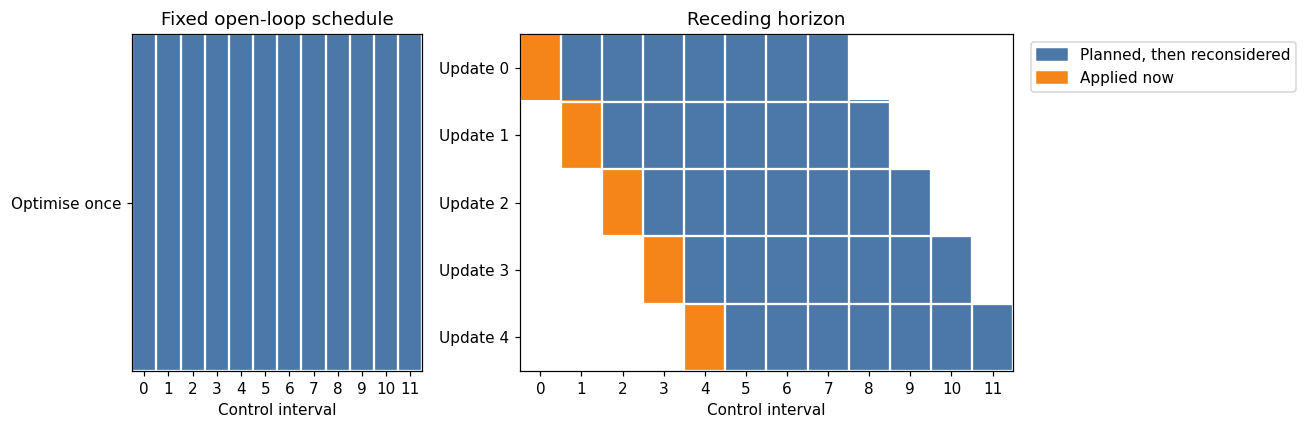

In [3]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

display_horizon = 8
updates_to_show = 5
timeline_columns = display_horizon + updates_to_show - 1

fixed_plan = np.ones((1, timeline_columns))
rolling_plan = np.zeros((updates_to_show, timeline_columns))
for update in range(updates_to_show):
    rolling_plan[update, update : update + display_horizon] = 1
    rolling_plan[update, update] = 2

colour_map = ListedColormap(["white", "#4C78A8", "#F58518"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1.7]})
axes[0].imshow(fixed_plan, cmap=colour_map, vmin=0, vmax=2, aspect="auto")
axes[0].set_yticks([0], ["Optimise once"])
axes[0].set_title("Fixed open-loop schedule")
axes[1].imshow(rolling_plan, cmap=colour_map, vmin=0, vmax=2, aspect="auto")
axes[1].set_yticks(range(updates_to_show), [f"Update {i}" for i in range(updates_to_show)])
axes[1].set_title("Receding horizon")
for axis in axes:
    axis.set_xticks(range(timeline_columns))
    axis.set_xlabel("Control interval")
    axis.set_xticks(np.arange(-0.5, timeline_columns, 1), minor=True)
    axis.set_yticks(np.arange(-0.5, axis.images[0].get_array().shape[0], 1), minor=True)
    axis.grid(which="minor", color="white", linewidth=1.5)
    axis.tick_params(which="minor", bottom=False, left=False)

axes[1].legend(
    handles=[
        Patch(color="#4C78A8", label="Planned, then reconsidered"),
        Patch(color="#F58518", label="Applied now"),
    ],
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
)
plt.tight_layout()
plt.show()

In [4]:
horizon_steps = 48
example_controller = build_mpc_problem(model, horizon_steps)
example_outdoor = forecast_vector(
    forecasts,
    first_origin,
    "outdoor_temperature_forecast_c",
    operation["outdoor_temperature_c"].iloc[0],
    horizon_steps,
)
example_horizon = operation.iloc[:horizon_steps]
example_controller["initial_temperature"].value = 20.0
example_controller["outdoor_temperature"].value = example_outdoor
example_controller["price"].value = example_horizon["import_price_gbp_per_kwh"].to_numpy()
example_controller["comfort_min"].value = example_horizon["comfort_min_c"].to_numpy()
example_controller["comfort_max"].value = example_horizon["comfort_max_c"].to_numpy()
example_controller["problem"].solve(solver=cp.CLARABEL)

print("Status:", example_controller["problem"].status)
print(f"First action applied: {example_controller['electric_power'].value[0]:.3f} kW")
print("The other 47 proposed actions will be reconsidered at the next update.")

Status: optimal
First action applied: 0.834 kW
The other 47 proposed actions will be reconsidered at the next update.


## 3. Task 1 — implement the receding-horizon loop

In [5]:
def run_mpc(
    operation,
    forecasts,
    model,
    evaluation_steps=48,
    horizon_steps=48,
    plant_class=TwoStateReferencePlant,
):
    controller = build_mpc_problem(model, horizon_steps)
    plant = plant_class(
        step_hours=model["sampling_interval_hours"],
        random_state=88,
    )
    measured_temperature = plant.reset(20.0, 20.0)
    records = []

    for position in range(evaluation_steps):
        timestamp = operation.index[position]
        horizon = operation.iloc[position : position + horizon_steps]
        outdoor_forecast = forecast_vector(
            forecasts,
            timestamp,
            "outdoor_temperature_forecast_c",
            operation["outdoor_temperature_c"].iloc[position],
            horizon_steps,
        )

        controller["initial_temperature"].value = measured_temperature
        controller["outdoor_temperature"].value = outdoor_forecast
        controller["price"].value = horizon["import_price_gbp_per_kwh"].to_numpy()
        controller["comfort_min"].value = horizon["comfort_min_c"].to_numpy()
        controller["comfort_max"].value = horizon["comfort_max_c"].to_numpy()
        controller["problem"].solve(solver=cp.CLARABEL, warm_start=True)

        status = controller["problem"].status
        fallback = status not in {cp.OPTIMAL, cp.OPTIMAL_INACCURATE}
        if fallback:
            action_kw = (
                model["heat_pump_max_electric_kw"]
                if measured_temperature < operation["comfort_min_c"].iloc[position]
                else 0.0
            )
            predicted_next = np.nan
        else:
            action_kw = float(controller["electric_power"].value[0])
            predicted_next = float(controller["temperature"].value[1])

        realised = operation.iloc[position]
        result = plant.step(
            action_kw / model["heat_pump_max_electric_kw"],
            realised["outdoor_temperature_c"],
            realised["solar_irradiance_w_m2"],
            realised["internal_gains_kw"],
        )
        records.append(
            {
                "timestamp": timestamp,
                "indoor_temperature_c": measured_temperature,
                "next_indoor_temperature_c": result["indoor_temperature_measured_c"],
                "predicted_next_temperature_c": predicted_next,
                "heat_pump_electric_kw": result["heat_pump_electric_kw"],
                "solver_status": status,
                "fallback": fallback,
            }
        )
        measured_temperature = result["indoor_temperature_measured_c"]

    return pd.DataFrame.from_records(records).set_index("timestamp")

In [6]:
mpc_results = run_mpc(operation, forecasts, model)
print(mpc_results["solver_status"].value_counts())
print(f"Fallback actions: {int(mpc_results['fallback'].sum())}")
display(mpc_results.head())

solver_status
optimal    48
Name: count, dtype: int64
Fallback actions: 0


,indoor_temperature_c,next_indoor_temperature_c,predicted_next_temperature_c,heat_pump_electric_kw,solver_status,fallback
timestamp,,,,,,
2025-02-03 00:00:00,19.963419,20.059101,20.0,0.928899,optimal,False
2025-02-03 00:30:00,20.059101,20.005812,20.0,0.721528,optimal,False
2025-02-03 01:00:00,20.005812,19.920487,20.0,0.854542,optimal,False
2025-02-03 01:30:00,19.920487,20.021881,20.0,1.084831,optimal,False
2025-02-03 02:00:00,20.021881,19.980172,20.0,0.855925,optimal,False


## 4. Compare three strategies on the same plant

Plots show when each controller acts, but they are not sufficient for comparison. Report total electrical energy, total energy cost, peak power, time outside the lower comfort bound, degree-hours of discomfort and maximum temperature deviation for every strategy.

In [7]:
fixed_solution = solve_heating_schedule(evaluation_conditions, model)
fixed_results = simulate_reference_schedule(
    evaluation_conditions,
    fixed_solution["electric_power_kw"],
    random_state=88,
)
thermostat_results = simulate_thermostat(evaluation_conditions, random_state=88)

comparison = pd.DataFrame(
    {
        "Thermostat": realised_metrics(thermostat_results, evaluation_conditions),
        "Fixed schedule": realised_metrics(fixed_results, evaluation_conditions),
        "MPC": realised_metrics(mpc_results, evaluation_conditions),
    }
).T
display(comparison.round(3))

relative_to_thermostat = pd.DataFrame(
    {
        "Energy change [%]": 100
        * (comparison["Energy [kWh]"] / comparison.loc["Thermostat", "Energy [kWh]"] - 1),
        "Cost change [%]": 100
        * (comparison["Cost [£]"] / comparison.loc["Thermostat", "Cost [£]"] - 1),
    }
)
display(relative_to_thermostat.round(1))

,Energy [kWh],Cost [£],Peak [kW],Violation [h],Degree-hours [°C h],Maximum deviation [°C]
Thermostat,17.500,3.975,5.0,4.5,1.017,0.350
Fixed schedule,20.045,4.633,5.0,4.0,0.186,0.117
MPC,16.050,3.459,5.0,5.5,0.744,0.377


,Energy change [%],Cost change [%]
Thermostat,0.0,0.0
Fixed schedule,14.5,16.6
MPC,-8.3,-13.0


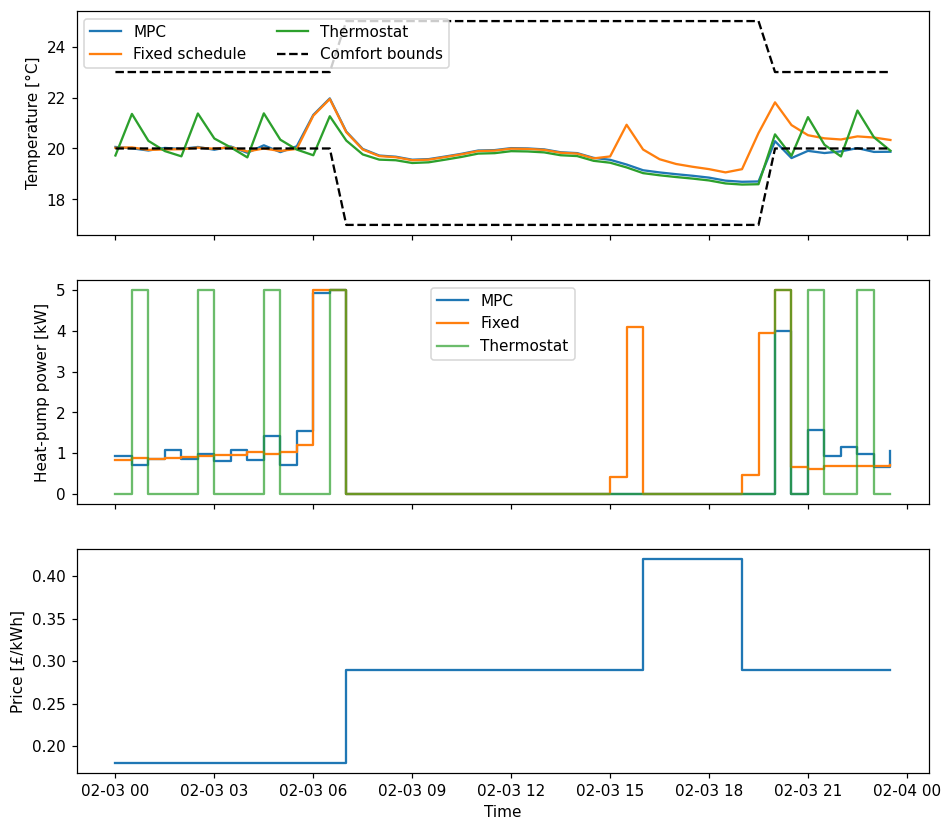

In [8]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 9))
axes[0].plot(mpc_results["next_indoor_temperature_c"], label="MPC")
axes[0].plot(fixed_results["next_indoor_temperature_c"], label="Fixed schedule")
axes[0].plot(thermostat_results["next_indoor_temperature_c"], label="Thermostat")
axes[0].plot(evaluation_conditions["comfort_min_c"], "--", color="black", label="Comfort bounds")
axes[0].plot(evaluation_conditions["comfort_max_c"], "--", color="black")
axes[0].set_ylabel("Temperature [°C]")
axes[0].legend(ncol=2)
axes[1].step(mpc_results.index, mpc_results["heat_pump_electric_kw"], where="post", label="MPC")
axes[1].step(fixed_results.index, fixed_results["heat_pump_electric_kw"], where="post", label="Fixed")
axes[1].step(thermostat_results.index, thermostat_results["heat_pump_electric_kw"], where="post", label="Thermostat", alpha=0.7)
axes[1].set_ylabel("Heat-pump power [kW]")
axes[1].legend()
axes[2].step(evaluation_conditions.index, evaluation_conditions["import_price_gbp_per_kwh"], where="post")
axes[2].set_ylabel("Price [£/kWh]")
axes[2].set_xlabel("Time")
plt.show()

## Discussion

1. Which information changes between two MPC updates?
2. Why can MPC correct accumulated state error while a fixed schedule cannot?
3. What errors remain until the next measurement?
4. Why must a safe fallback be defined before running the controller?